# Detección de Anomalías en Ciberseguridad con PCAP

## Introducción

En este notebook exploraremos técnicas de Machine Learning para detectar anomalías en tráfico de red usando archivos PCAP (Packet Capture). Los archivos PCAP contienen capturas de tráfico de red que podemos analizar para identificar:

- **Ataques DDoS**: Patrones anormales de tráfico
- **Port Scanning**: Intentos de escaneo de puertos
- **Tráfico malicioso**: Comunicaciones sospechosas
- **Exfiltración de datos**: Transferencias inusuales

### Técnicas que usaremos:

1. **Isolation Forest**: Detecta outliers aislando observaciones
2. **One-Class SVM**: Aprende el "comportamiento normal" y detecta desviaciones
3. **Local Outlier Factor (LOF)**: Detecta anomalías basándose en densidad local
4. **Autoencoder**: Red neuronal que detecta anomalías por error de reconstrucción

## 1. Instalación de Dependencias

Para trabajar con archivos PCAP, necesitamos instalar las siguientes librerías:

## 1.1 Cómo Cargar un Archivo PCAP

Si tienes un archivo PCAP, hay varias formas de cargarlo:

### Opción 1: Usando Scapy (Recomendado)
```python
from scapy.all import rdpcap

# Cargar el archivo PCAP
packets = rdpcap('tu_archivo.pcap')
print(f"Número de paquetes: {len(packets)}")
```

### Opción 2: Usando PyShark (alternativa)
```python
import pyshark
cap = pyshark.FileCapture('tu_archivo.pcap')
```

### Opción 3: Convertir PCAP a CSV con tshark
```bash
tshark -r archivo.pcap -T fields -e frame.time -e ip.src -e ip.dst -e tcp.srcport -e tcp.dstport -E header=y -E separator=, > salida.csv
```

**Archivos PCAP de ejemplo para practicar:**
- [Wireshark Sample Captures](https://wiki.wireshark.org/SampleCaptures)
- [Malware Traffic Analysis](https://www.malware-traffic-analysis.net/)
- [CICIDS2017 Dataset](https://www.unb.ca/cic/datasets/ids-2017.html)

In [2]:
# Instalación de librerías necesarias
# !pip install scapy pandas numpy scikit-learn matplotlib seaborn
%pip install scapy


   ---------------------------------------- 0.0/2.6 MB ? eta -:--:--
   ---------------------------------------- 2.6/2.6 MB 29.9 MB/s  0:00:00



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Imports
import warnings
warnings.filterwarnings('ignore')

# Librerías para análisis de datos y visualización
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Scapy para leer archivos PCAP
try:
    from scapy.all import rdpcap, IP, TCP, UDP, ICMP
    SCAPY_AVAILABLE = True
except ImportError:
    print("Scapy no está instalado. Usaremos datos sintéticos.")
    SCAPY_AVAILABLE = False

# Sklearn para detección de anomalías
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, confusion_matrix

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

## 2. Generación de Datos Sintéticos de Tráfico de Red

Vamos a crear un dataset sintético que simula tráfico de red normal y anómalo. En un caso real, extraeríamos estas características de un archivo PCAP.

In [4]:
def generar_trafico_normal(n_samples=1000):
    """
    Genera tráfico de red normal
    """
    np.random.seed(42)
    
    data = {
        # Tamaño de paquete (bytes)
        'packet_size': np.random.normal(500, 150, n_samples),
        
        # Tasa de paquetes por segundo
        'packets_per_sec': np.random.normal(50, 15, n_samples),
        
        # Duración de la conexión (segundos)
        'duration': np.random.exponential(5, n_samples),
        
        # Número de puertos únicos contactados
        'unique_ports': np.random.poisson(3, n_samples),
        
        # Bytes enviados
        'bytes_sent': np.random.normal(10000, 3000, n_samples),
        
        # Bytes recibidos
        'bytes_received': np.random.normal(8000, 2500, n_samples),
        
        # Ratio de paquetes TCP/UDP
        'tcp_ratio': np.random.beta(8, 2, n_samples),
        
        # Número de conexiones fallidas
        'failed_connections': np.random.poisson(1, n_samples),
        
        # Flag SYN count (normal en establecimiento de conexión)
        'syn_count': np.random.poisson(2, n_samples),
        
        # Etiqueta
        'anomaly': 0
    }
    
    return pd.DataFrame(data)

def generar_trafico_anomalo(n_samples=100):
    """
    Genera diferentes tipos de tráfico anómalo
    """
    np.random.seed(123)
    
    # Tipo 1: DDoS - Alta tasa de paquetes pequeños
    ddos = {
        'packet_size': np.random.normal(64, 10, n_samples//3),
        'packets_per_sec': np.random.normal(500, 100, n_samples//3),
        'duration': np.random.exponential(0.5, n_samples//3),
        'unique_ports': np.random.poisson(1, n_samples//3),
        'bytes_sent': np.random.normal(50000, 10000, n_samples//3),
        'bytes_received': np.random.normal(1000, 200, n_samples//3),
        'tcp_ratio': np.random.beta(2, 8, n_samples//3),
        'failed_connections': np.random.poisson(0, n_samples//3),
        'syn_count': np.random.poisson(100, n_samples//3),
        'anomaly': 1,
        'anomaly_type': 'DDoS'
    }
    
    # Tipo 2: Port Scanning - Muchos puertos, conexiones cortas
    port_scan = {
        'packet_size': np.random.normal(40, 5, n_samples//3),
        'packets_per_sec': np.random.normal(200, 50, n_samples//3),
        'duration': np.random.exponential(0.1, n_samples//3),
        'unique_ports': np.random.poisson(50, n_samples//3),
        'bytes_sent': np.random.normal(5000, 1000, n_samples//3),
        'bytes_received': np.random.normal(2000, 500, n_samples//3),
        'tcp_ratio': np.random.beta(9, 1, n_samples//3),
        'failed_connections': np.random.poisson(20, n_samples//3),
        'syn_count': np.random.poisson(50, n_samples//3),
        'anomaly': 1,
        'anomaly_type': 'Port_Scan'
    }
    
    # Tipo 3: Exfiltración de datos - Alto volumen de salida
    exfiltration = {
        'packet_size': np.random.normal(1400, 200, n_samples//3),
        'packets_per_sec': np.random.normal(100, 20, n_samples//3),
        'duration': np.random.exponential(30, n_samples//3),
        'unique_ports': np.random.poisson(1, n_samples//3),
        'bytes_sent': np.random.normal(100000, 20000, n_samples//3),
        'bytes_received': np.random.normal(5000, 1000, n_samples//3),
        'tcp_ratio': np.random.beta(7, 3, n_samples//3),
        'failed_connections': np.random.poisson(0, n_samples//3),
        'syn_count': np.random.poisson(1, n_samples//3),
        'anomaly': 1,
        'anomaly_type': 'Data_Exfiltration'
    }
    
    # Combinar todos los tipos de anomalías
    df_ddos = pd.DataFrame(ddos)
    df_port_scan = pd.DataFrame(port_scan)
    df_exfiltration = pd.DataFrame(exfiltration)
    
    return pd.concat([df_ddos, df_port_scan, df_exfiltration], ignore_index=True)

# Generar dataset
df_normal = generar_trafico_normal(1000)
df_anomalo = generar_trafico_anomalo(150)

# Combinar y mezclar
df = pd.concat([df_normal, df_anomalo], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dataset generado: {len(df)} muestras")
print(f"Tráfico normal: {len(df[df['anomaly']==0])} ({len(df[df['anomaly']==0])/len(df)*100:.1f}%)")
print(f"Tráfico anómalo: {len(df[df['anomaly']==1])} ({len(df[df['anomaly']==1])/len(df)*100:.1f}%)")

df.head(10)

Dataset generado: 1150 muestras
Tráfico normal: 1000 (87.0%)
Tráfico anómalo: 150 (13.0%)


,packet_size,packets_per_sec,duration,unique_ports,bytes_sent,bytes_received,tcp_ratio,failed_connections,syn_count,anomaly,anomaly_type
0,541.503620,38.690531,7.579194,3,10101.169309,7669.990368,0.706808,1,2,0,NaN
1,353.619012,40.188865,2.841146,6,8501.159220,2867.813949,0.864508,1,2,0,NaN
2,613.626157,55.920073,2.032703,5,15182.656128,5224.528005,0.889311,2,2,0,NaN
3,381.121889,44.313084,15.123727,3,5552.757577,6211.878703,0.927403,1,4,0,NaN
4,725.598948,42.428376,0.625273,1,13800.541722,6526.523513,0.952016,0,2,0,NaN
5,427.195468,37.469794,3.771494,1,6485.486775,5740.361145,0.973584,0,1,0,NaN
6,550.168518,66.900577,4.175636,5,6432.933822,7259.377003,0.741312,0,3,0,NaN
7,809.112189,58.074441,14.695878,2,10898.597509,13215.938544,0.848324,0,3,0,NaN
8,721.303433,22.970293,0.191475,6,7697.857581,9003.017909,0.899442,0,5,0,NaN
9,593.617973,31.854579,3.441195,4,10081.766897,9009.788953,0.905594,1,2,0,NaN


## 3. Análisis Exploratorio de Datos (EDA)

In [5]:
# Estadísticas descriptivas
print("=" * 50)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 50)
df.describe()

ESTADÍSTICAS DESCRIPTIVAS


,packet_size,packets_per_sec,duration,unique_ports,bytes_sent,bytes_received,tcp_ratio,failed_connections,syn_count,anomaly
count,1150.000000,1150.000000,1150.000000,1150.000000,1150.000000,1150.000000,1150.000000,1150.000000,1150.000000,1150.000000
mean,502.654698,79.626207,5.594441,4.806957,15570.018129,7312.192626,0.779295,1.759130,8.465217,0.130435
std,269.429569,100.296776,8.666809,9.727942,21566.878910,3102.095838,0.172034,4.167958,22.286061,0.336928
min,13.809899,5.894170,0.000058,0.000000,236.563176,-368.876491,0.032125,0.000000,0.000000,0.000000
25%,374.374695,42.935101,1.095270,2.000000,7648.095222,5424.637561,0.715572,0.000000,1.000000,0.000000
50%,494.772480,53.907467,3.123931,3.000000,10078.340342,7465.533428,0.820468,1.000000,2.000000,0.000000
75%,602.290640,67.228842,6.924383,4.000000,12593.075805,9573.445189,0.895611,2.000000,3.000000,0.000000
max,1709.584653,708.711336,86.581143,67.000000,147427.769081,16190.998363,0.999592,30.000000,123.000000,1.000000


In [6]:
# Distribución de tipos de anomalías
if 'anomaly_type' in df.columns:
    print("\nDistribución de tipos de anomalías:")
    print(df[df['anomaly']==1]['anomaly_type'].value_counts())


Distribución de tipos de anomalías:
anomaly_type
DDoS                 50
Data_Exfiltration    50
Port_Scan            50
Name: count, dtype: int64


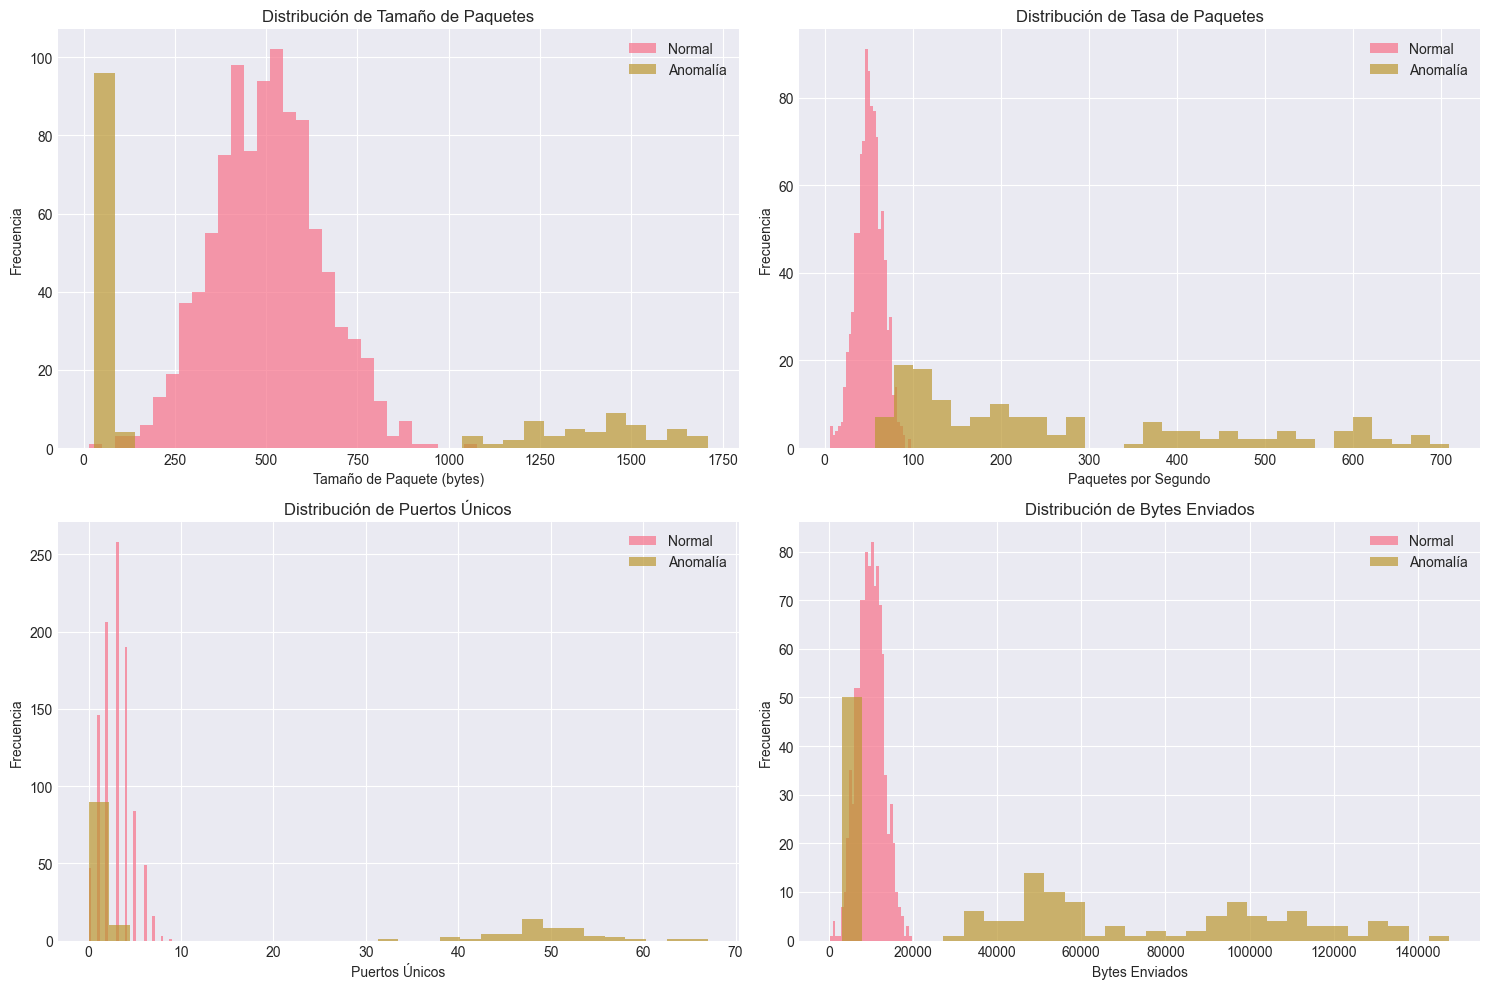

In [7]:
# Visualización de características principales
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Packet Size
axes[0, 0].hist(df[df['anomaly']==0]['packet_size'], alpha=0.7, label='Normal', bins=30)
axes[0, 0].hist(df[df['anomaly']==1]['packet_size'], alpha=0.7, label='Anomalía', bins=30)
axes[0, 0].set_xlabel('Tamaño de Paquete (bytes)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].legend()
axes[0, 0].set_title('Distribución de Tamaño de Paquetes')

# Packets per Second
axes[0, 1].hist(df[df['anomaly']==0]['packets_per_sec'], alpha=0.7, label='Normal', bins=30)
axes[0, 1].hist(df[df['anomaly']==1]['packets_per_sec'], alpha=0.7, label='Anomalía', bins=30)
axes[0, 1].set_xlabel('Paquetes por Segundo')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].legend()
axes[0, 1].set_title('Distribución de Tasa de Paquetes')

# Unique Ports
axes[1, 0].hist(df[df['anomaly']==0]['unique_ports'], alpha=0.7, label='Normal', bins=30)
axes[1, 0].hist(df[df['anomaly']==1]['unique_ports'], alpha=0.7, label='Anomalía', bins=30)
axes[1, 0].set_xlabel('Puertos Únicos')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].legend()
axes[1, 0].set_title('Distribución de Puertos Únicos')

# Bytes Sent
axes[1, 1].hist(df[df['anomaly']==0]['bytes_sent'], alpha=0.7, label='Normal', bins=30)
axes[1, 1].hist(df[df['anomaly']==1]['bytes_sent'], alpha=0.7, label='Anomalía', bins=30)
axes[1, 1].set_xlabel('Bytes Enviados')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].legend()
axes[1, 1].set_title('Distribución de Bytes Enviados')

plt.tight_layout()
plt.show()

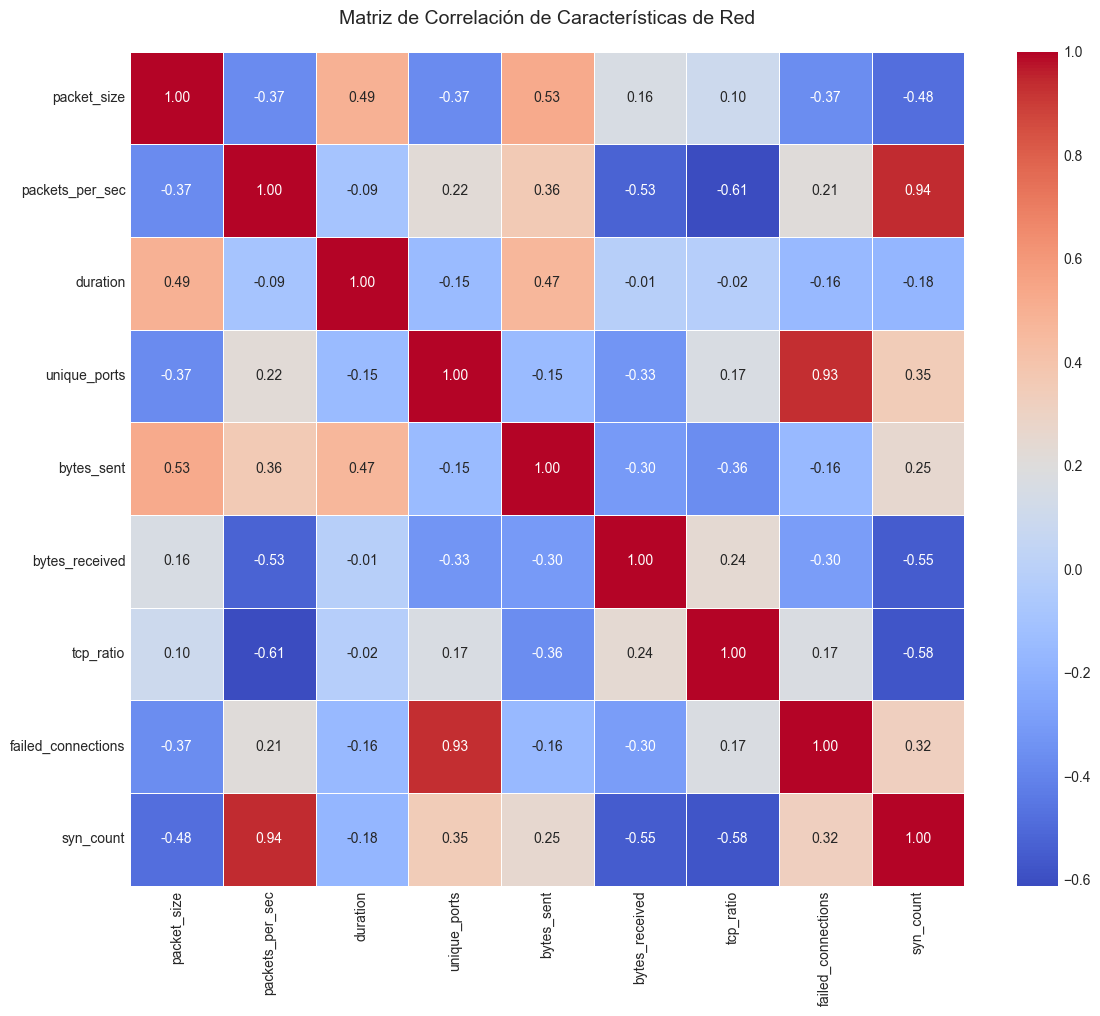

In [8]:
# Matriz de correlación
features = ['packet_size', 'packets_per_sec', 'duration', 'unique_ports', 
            'bytes_sent', 'bytes_received', 'tcp_ratio', 'failed_connections', 'syn_count']

plt.figure(figsize=(12, 10))
correlation_matrix = df[features].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=0.5)
plt.title('Matriz de Correlación de Características de Red', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

## 4. Preprocesamiento de Datos

In [9]:
# Separar características y etiquetas
X = df[features].copy()
y = df['anomaly'].copy()

# Guardar para comparación posterior
y_true = y.copy()

# Normalización de características
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=features)

print("Características normalizadas:")
print(X_scaled.describe())

Características normalizadas:
        packet_size  packets_per_sec      duration  unique_ports  \
count  1.150000e+03     1.150000e+03  1.150000e+03  1.150000e+03   
mean  -7.877756e-17    -3.089316e-17 -3.861645e-17 -2.471453e-17   
std    1.000435e+00     1.000435e+00  1.000435e+00  1.000435e+00   
min   -1.815159e+00    -7.354585e-01 -6.457759e-01 -4.943541e-01   
25%   -4.763242e-01    -3.659845e-01 -5.193524e-01 -2.886713e-01   
50%   -2.926794e-02    -2.565379e-01 -2.851781e-01 -1.858299e-01   
75%    3.699642e-01    -1.236606e-01  1.535192e-01 -8.298853e-02   
max    4.481524e+00     6.274966e+00  9.348532e+00  6.396019e+00   

         bytes_sent  bytes_received     tcp_ratio  failed_connections  \
count  1.150000e+03    1.150000e+03  1.150000e+03        1.150000e+03   
mean   4.942906e-17   -2.347880e-16  2.316987e-16        6.178632e-18   
std    1.000435e+00    1.000435e+00  1.000435e+00        1.000435e+00   
min   -7.112817e-01   -2.477167e+00 -4.345049e+00       -4.222442

## 5. Modelos de Detección de Anomalías

### 5.1 Isolation Forest

Isolation Forest funciona "aislando" observaciones. Las anomalías son más fáciles de aislar que las observaciones normales.

In [10]:
# Entrenar Isolation Forest
# contamination: proporción esperada de anomalías en el dataset
iso_forest = IsolationForest(
    contamination=0.13,  # ~13% de anomalías en nuestro dataset
    random_state=42,
    n_estimators=100
)

# Predecir (-1 para anomalías, 1 para normal)
y_pred_iso = iso_forest.fit_predict(X_scaled)

# Convertir a 0/1 (0=normal, 1=anomalía)
y_pred_iso = np.where(y_pred_iso == -1, 1, 0)

# Obtener scores de anomalía
anomaly_scores_iso = iso_forest.score_samples(X_scaled)

print("=" * 50)
print("ISOLATION FOREST - Resultados")
print("=" * 50)
print(f"Anomalías detectadas: {sum(y_pred_iso)}")
print(f"Anomalías reales: {sum(y_true)}")
print("\nReporte de Clasificación:")
print(classification_report(y_true, y_pred_iso, target_names=['Normal', 'Anomalía']))

ISOLATION FOREST - Resultados
Anomalías detectadas: 150
Anomalías reales: 150

Reporte de Clasificación:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      1000
    Anomalía       0.99      0.99      0.99       150

    accuracy                           1.00      1150
   macro avg       1.00      1.00      1.00      1150
weighted avg       1.00      1.00      1.00      1150



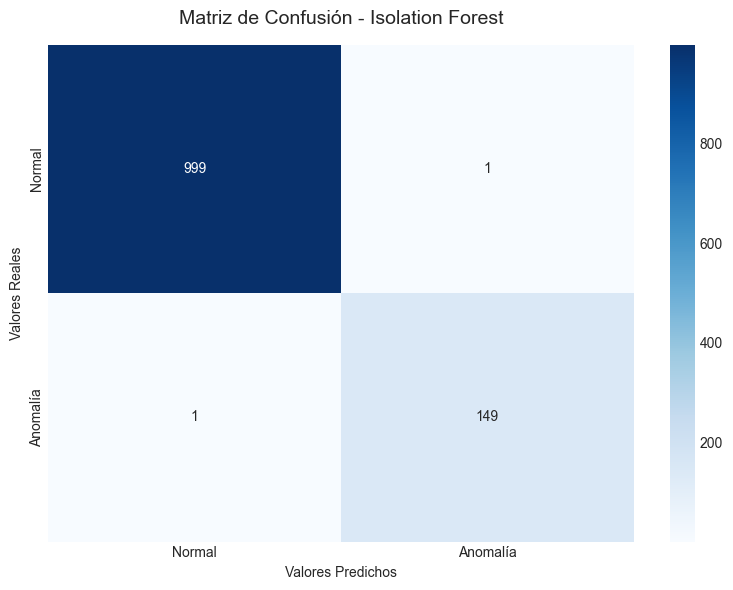

In [11]:
# Matriz de confusión - Isolation Forest
cm_iso = confusion_matrix(y_true, y_pred_iso)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_iso, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Anomalía'],
            yticklabels=['Normal', 'Anomalía'])
plt.title('Matriz de Confusión - Isolation Forest', fontsize=14, pad=15)
plt.ylabel('Valores Reales')
plt.xlabel('Valores Predichos')
plt.tight_layout()
plt.show()

### 5.2 One-Class SVM

One-Class SVM aprende los límites de la clase "normal" y clasifica todo lo que esté fuera como anomalía.

In [12]:
# Entrenar One-Class SVM
oc_svm = OneClassSVM(
    kernel='rbf',
    gamma='auto',
    nu=0.13  # proporción esperada de anomalías
)

# Predecir
y_pred_svm = oc_svm.fit_predict(X_scaled)
y_pred_svm = np.where(y_pred_svm == -1, 1, 0)

print("=" * 50)
print("ONE-CLASS SVM - Resultados")
print("=" * 50)
print(f"Anomalías detectadas: {sum(y_pred_svm)}")
print(f"Anomalías reales: {sum(y_true)}")
print("\nReporte de Clasificación:")
print(classification_report(y_true, y_pred_svm, target_names=['Normal', 'Anomalía']))

ONE-CLASS SVM - Resultados
Anomalías detectadas: 150
Anomalías reales: 150

Reporte de Clasificación:
              precision    recall  f1-score   support

      Normal       0.95      0.95      0.95      1000
    Anomalía       0.68      0.68      0.68       150

    accuracy                           0.92      1150
   macro avg       0.82      0.82      0.82      1150
weighted avg       0.92      0.92      0.92      1150



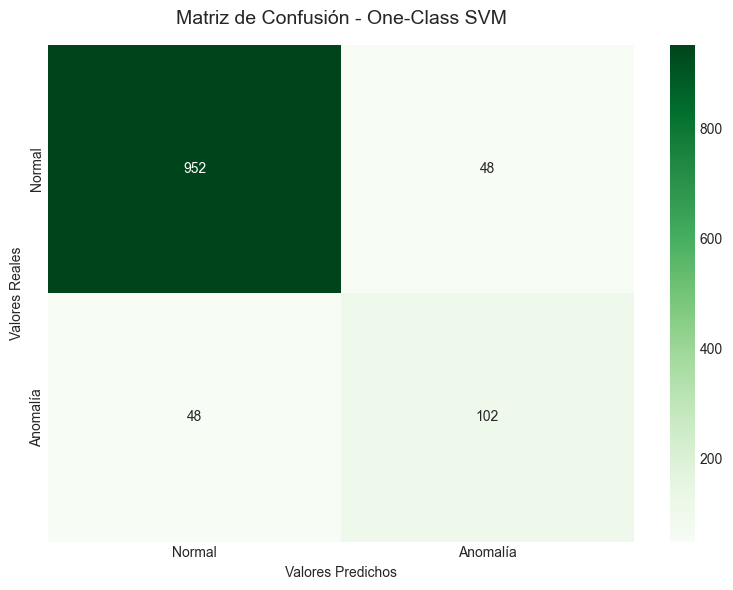

In [13]:
# Matriz de confusión - One-Class SVM
cm_svm = confusion_matrix(y_true, y_pred_svm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Normal', 'Anomalía'],
            yticklabels=['Normal', 'Anomalía'])
plt.title('Matriz de Confusión - One-Class SVM', fontsize=14, pad=15)
plt.ylabel('Valores Reales')
plt.xlabel('Valores Predichos')
plt.tight_layout()
plt.show()

### 5.3 Local Outlier Factor (LOF)

LOF detecta anomalías basándose en la densidad local de las observaciones.

In [14]:
# Entrenar Local Outlier Factor
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.13
)

# Predecir
y_pred_lof = lof.fit_predict(X_scaled)
y_pred_lof = np.where(y_pred_lof == -1, 1, 0)

# LOF scores (más negativo = más anómalo)
lof_scores = lof.negative_outlier_factor_

print("=" * 50)
print("LOCAL OUTLIER FACTOR - Resultados")
print("=" * 50)
print(f"Anomalías detectadas: {sum(y_pred_lof)}")
print(f"Anomalías reales: {sum(y_true)}")
print("\nReporte de Clasificación:")
print(classification_report(y_true, y_pred_lof, target_names=['Normal', 'Anomalía']))

LOCAL OUTLIER FACTOR - Resultados
Anomalías detectadas: 150
Anomalías reales: 150

Reporte de Clasificación:
              precision    recall  f1-score   support

      Normal       0.88      0.88      0.88      1000
    Anomalía       0.17      0.17      0.17       150

    accuracy                           0.78      1150
   macro avg       0.52      0.52      0.52      1150
weighted avg       0.78      0.78      0.78      1150



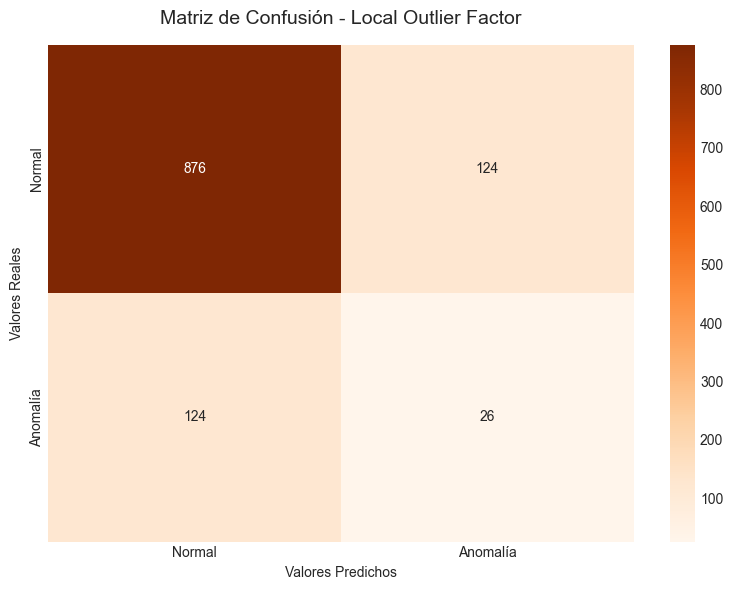

In [15]:
# Matriz de confusión - LOF
cm_lof = confusion_matrix(y_true, y_pred_lof)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lof, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal', 'Anomalía'],
            yticklabels=['Normal', 'Anomalía'])
plt.title('Matriz de Confusión - Local Outlier Factor', fontsize=14, pad=15)
plt.ylabel('Valores Reales')
plt.xlabel('Valores Predichos')
plt.tight_layout()
plt.show()

## 6. Comparación de Modelos

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calcular métricas para cada modelo
modelos = ['Isolation Forest', 'One-Class SVM', 'LOF']
predicciones = [y_pred_iso, y_pred_svm, y_pred_lof]

resultados = []
for modelo, y_pred in zip(modelos, predicciones):
    resultados.append({
        'Modelo': modelo,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    })

df_resultados = pd.DataFrame(resultados)
print("\n" + "="*70)
print("COMPARACIÓN DE MODELOS")
print("="*70)
print(df_resultados.to_string(index=False))
print("="*70)


COMPARACIÓN DE MODELOS
          Modelo  Accuracy  Precision   Recall  F1-Score
Isolation Forest  0.998261   0.993333 0.993333  0.993333
   One-Class SVM  0.916522   0.680000 0.680000  0.680000
             LOF  0.784348   0.173333 0.173333  0.173333


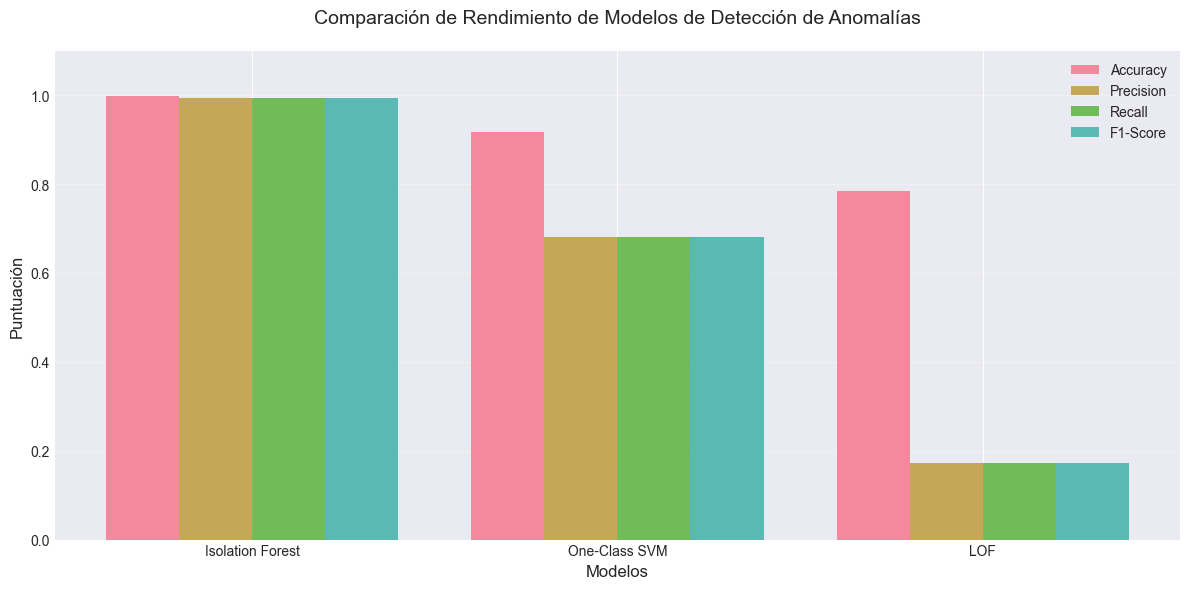

In [17]:
# Visualización comparativa
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(modelos))
width = 0.2

ax.bar(x - 1.5*width, df_resultados['Accuracy'], width, label='Accuracy', alpha=0.8)
ax.bar(x - 0.5*width, df_resultados['Precision'], width, label='Precision', alpha=0.8)
ax.bar(x + 0.5*width, df_resultados['Recall'], width, label='Recall', alpha=0.8)
ax.bar(x + 1.5*width, df_resultados['F1-Score'], width, label='F1-Score', alpha=0.8)

ax.set_xlabel('Modelos', fontsize=12)
ax.set_ylabel('Puntuación', fontsize=12)
ax.set_title('Comparación de Rendimiento de Modelos de Detección de Anomalías', 
             fontsize=14, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(modelos)
ax.legend()
ax.set_ylim([0, 1.1])
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Visualización con PCA

Vamos a reducir las dimensiones a 2D para visualizar las anomalías detectadas.

In [18]:
# Aplicar PCA para reducir a 2 dimensiones
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"Varianza explicada por componentes: {pca.explained_variance_ratio_}")
print(f"Varianza total explicada: {sum(pca.explained_variance_ratio_):.2%}")

Varianza explicada por componentes: [0.3761978  0.26947433]
Varianza total explicada: 64.57%


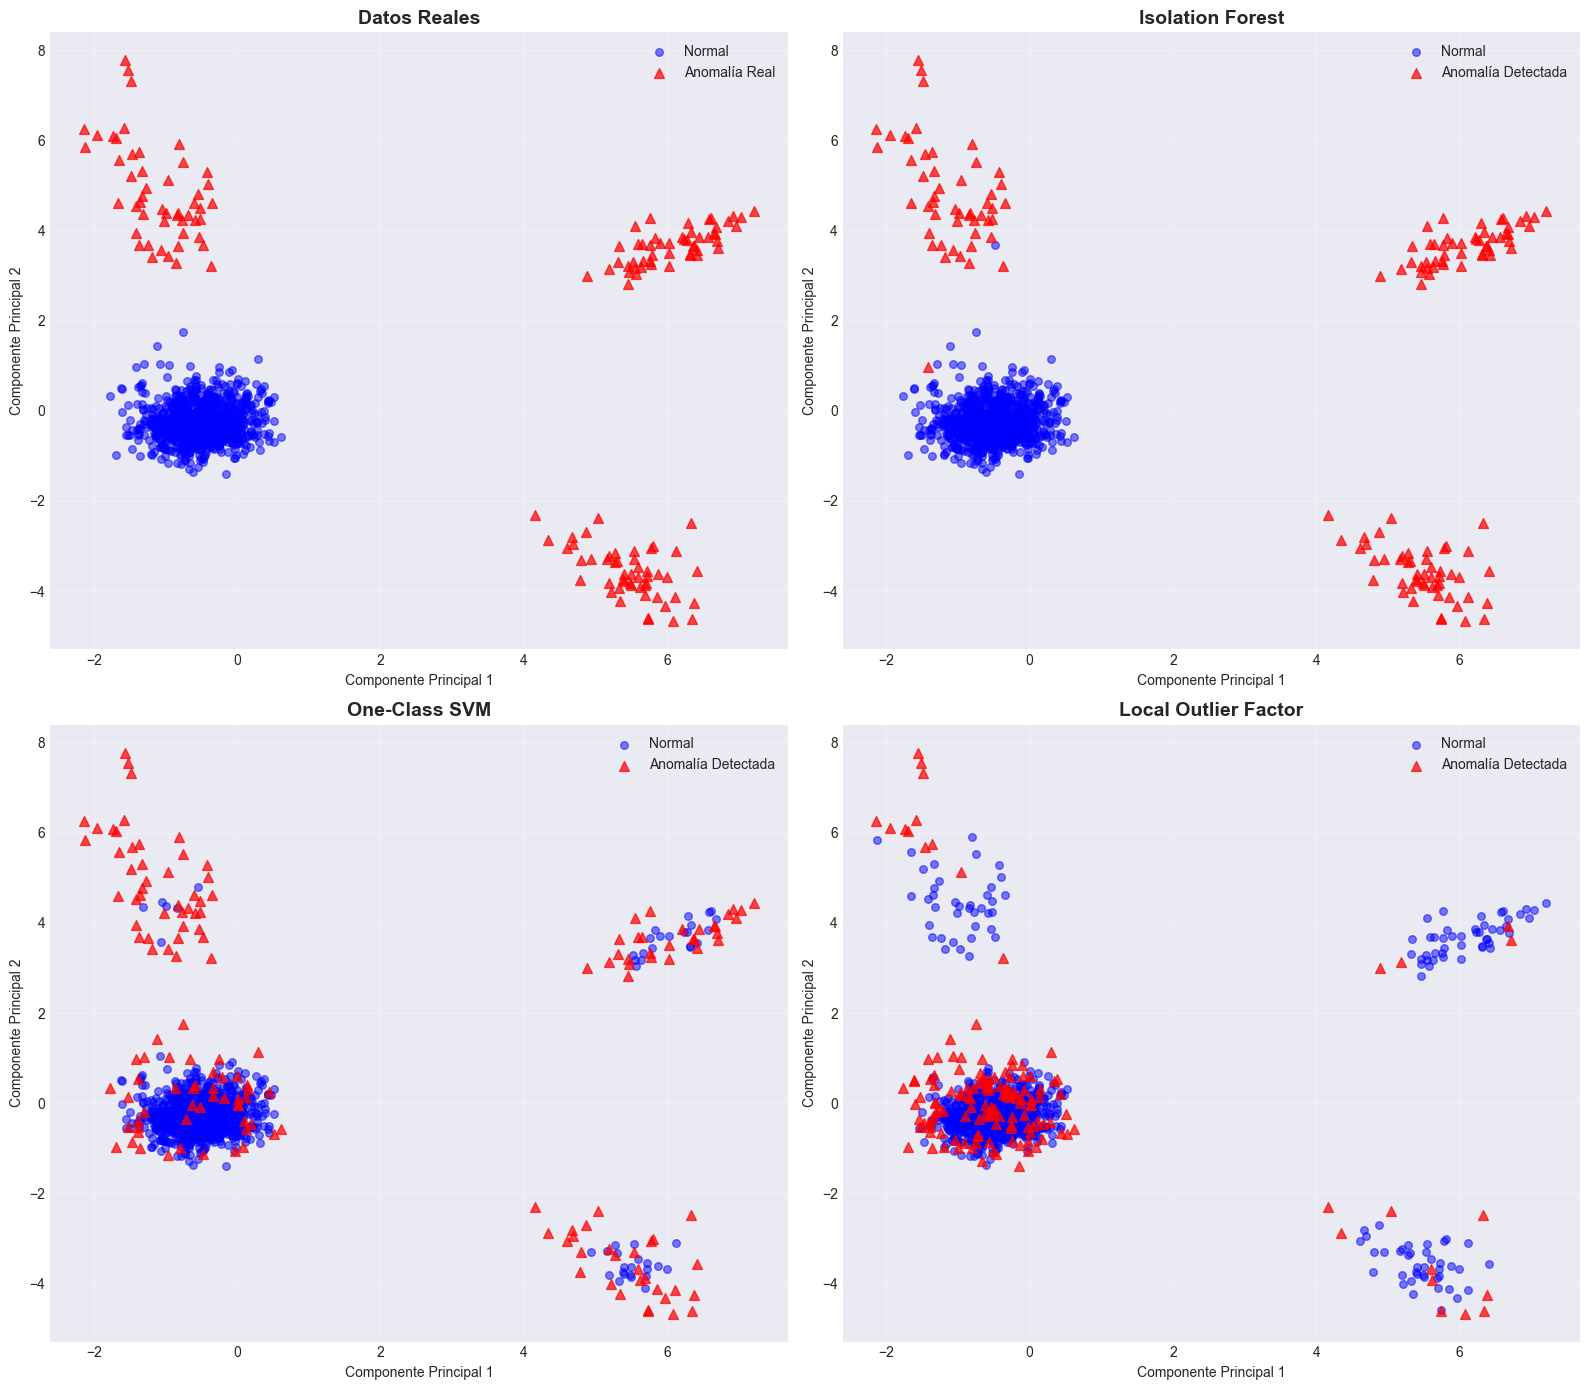

In [19]:
# Visualización de resultados con PCA
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Datos reales
scatter1 = axes[0, 0].scatter(X_pca[y_true == 0, 0], X_pca[y_true == 0, 1], 
                               c='blue', alpha=0.5, s=30, label='Normal')
scatter2 = axes[0, 0].scatter(X_pca[y_true == 1, 0], X_pca[y_true == 1, 1], 
                               c='red', alpha=0.7, s=50, marker='^', label='Anomalía Real')
axes[0, 0].set_title('Datos Reales', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Componente Principal 1')
axes[0, 0].set_ylabel('Componente Principal 2')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Isolation Forest
axes[0, 1].scatter(X_pca[y_pred_iso == 0, 0], X_pca[y_pred_iso == 0, 1], 
                   c='blue', alpha=0.5, s=30, label='Normal')
axes[0, 1].scatter(X_pca[y_pred_iso == 1, 0], X_pca[y_pred_iso == 1, 1], 
                   c='red', alpha=0.7, s=50, marker='^', label='Anomalía Detectada')
axes[0, 1].set_title('Isolation Forest', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Componente Principal 1')
axes[0, 1].set_ylabel('Componente Principal 2')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# One-Class SVM
axes[1, 0].scatter(X_pca[y_pred_svm == 0, 0], X_pca[y_pred_svm == 0, 1], 
                   c='blue', alpha=0.5, s=30, label='Normal')
axes[1, 0].scatter(X_pca[y_pred_svm == 1, 0], X_pca[y_pred_svm == 1, 1], 
                   c='red', alpha=0.7, s=50, marker='^', label='Anomalía Detectada')
axes[1, 0].set_title('One-Class SVM', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Componente Principal 1')
axes[1, 0].set_ylabel('Componente Principal 2')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# LOF
axes[1, 1].scatter(X_pca[y_pred_lof == 0, 0], X_pca[y_pred_lof == 0, 1], 
                   c='blue', alpha=0.5, s=30, label='Normal')
axes[1, 1].scatter(X_pca[y_pred_lof == 1, 0], X_pca[y_pred_lof == 1, 1], 
                   c='red', alpha=0.7, s=50, marker='^', label='Anomalía Detectada')
axes[1, 1].set_title('Local Outlier Factor', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Componente Principal 1')
axes[1, 1].set_ylabel('Componente Principal 2')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Análisis de Anomalías Detectadas

Vamos a analizar en detalle las anomalías detectadas por el mejor modelo.

In [20]:
# Usar Isolation Forest como modelo principal (generalmente el mejor)
df['predicted_anomaly'] = y_pred_iso
df['anomaly_score'] = anomaly_scores_iso

# Top 10 anomalías más fuertes
top_anomalias = df[df['predicted_anomaly'] == 1].nsmallest(10, 'anomaly_score')

print("\n" + "="*70)
print("TOP 10 ANOMALÍAS MÁS FUERTES DETECTADAS")
print("="*70)
print(top_anomalias[['packet_size', 'packets_per_sec', 'unique_ports', 
                      'bytes_sent', 'syn_count', 'anomaly_score']].to_string())


TOP 10 ANOMALÍAS MÁS FUERTES DETECTADAS
      packet_size  packets_per_sec  unique_ports     bytes_sent  syn_count  anomaly_score
934   1507.584612       123.487563             1  104316.033911          0      -0.680276
1118  1214.212456       131.464793             0  124150.605317          4      -0.674125
59    1316.648466        92.678366             3  110958.479165          2      -0.656968
788   1413.343062       125.057695             0   98295.892154          0      -0.647004
602     41.376709       163.186803            55    6079.796350         59      -0.646317
821     66.829785       674.371223             0   59566.019311        105      -0.645722
104   1652.051357       122.647516             0   95581.080593          2      -0.644663
988     80.514365       606.931597             0   36253.120290         96      -0.644507
1030    36.059172       141.286485            60    5892.200085         67      -0.640480
877     52.799251       276.272212            42    3817.84

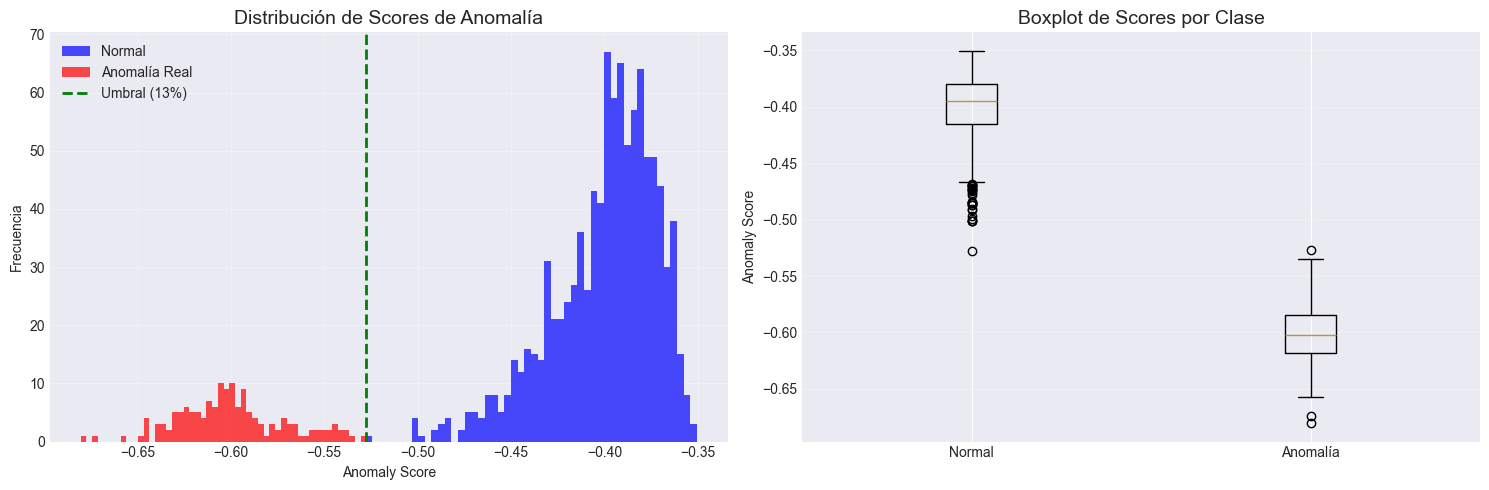

In [21]:
# Distribución de scores de anomalía
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df[df['anomaly'] == 0]['anomaly_score'], bins=50, 
             alpha=0.7, label='Normal', color='blue')
axes[0].hist(df[df['anomaly'] == 1]['anomaly_score'], bins=50, 
             alpha=0.7, label='Anomalía Real', color='red')
axes[0].axvline(x=np.percentile(anomaly_scores_iso, 13), 
                color='green', linestyle='--', linewidth=2, 
                label='Umbral (13%)')
axes[0].set_xlabel('Anomaly Score')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Scores de Anomalía', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
data_boxplot = [
    df[df['anomaly'] == 0]['anomaly_score'],
    df[df['anomaly'] == 1]['anomaly_score']
]
axes[1].boxplot(data_boxplot, labels=['Normal', 'Anomalía'])
axes[1].set_ylabel('Anomaly Score')
axes[1].set_title('Boxplot de Scores por Clase', fontsize=14)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 9. Análisis por Tipo de Anomalía


TASA DE DETECCIÓN POR TIPO DE ANOMALÍA
                   Detectadas  Total  Tasa_Deteccion
anomaly_type                                        
DDoS                       50     50           100.0
Data_Exfiltration          49     50            98.0
Port_Scan                  50     50           100.0


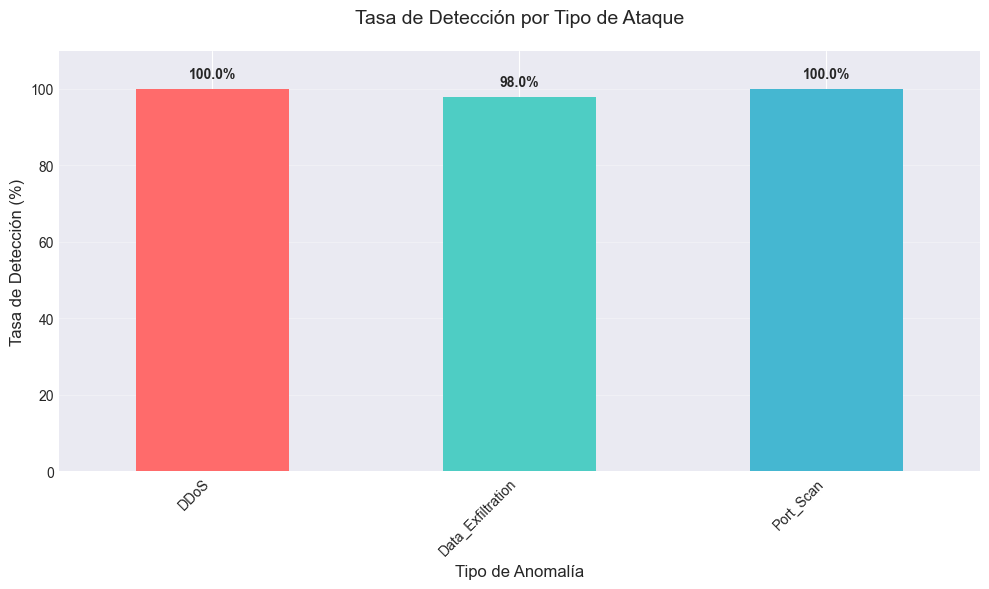

In [22]:
# Si tenemos tipos de anomalías
if 'anomaly_type' in df.columns:
    df_anomalias = df[df['anomaly'] == 1].copy()
    
    # Tasa de detección por tipo
    deteccion_por_tipo = df_anomalias.groupby('anomaly_type').agg({
        'predicted_anomaly': ['sum', 'count']
    })
    deteccion_por_tipo.columns = ['Detectadas', 'Total']
    deteccion_por_tipo['Tasa_Deteccion'] = \
        (deteccion_por_tipo['Detectadas'] / deteccion_por_tipo['Total'] * 100).round(2)
    
    print("\n" + "="*70)
    print("TASA DE DETECCIÓN POR TIPO DE ANOMALÍA")
    print("="*70)
    print(deteccion_por_tipo)
    
    # Visualización
    fig, ax = plt.subplots(figsize=(10, 6))
    deteccion_por_tipo['Tasa_Deteccion'].plot(kind='bar', ax=ax, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    ax.set_ylabel('Tasa de Detección (%)', fontsize=12)
    ax.set_xlabel('Tipo de Anomalía', fontsize=12)
    ax.set_title('Tasa de Detección por Tipo de Ataque', fontsize=14, pad=20)
    ax.set_ylim([0, 110])
    ax.grid(axis='y', alpha=0.3)
    
    # Añadir valores encima de las barras
    for i, v in enumerate(deteccion_por_tipo['Tasa_Deteccion']):
        ax.text(i, v + 2, f'{v:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 10. Procesamiento de Archivos PCAP Reales

### 📁 Paso a Paso para Cargar tu PCAP

Si tienes un archivo PCAP en tu sistema, sigue estos pasos:

### Ejemplo 1: Carga Simple de PCAP

In [ ]:
# MÉTODO 1: Carga básica de un PCAP
# Reemplaza 'tu_archivo.pcap' con la ruta de tu archivo

if SCAPY_AVAILABLE:
    # Ejemplo de cómo cargarías tu archivo
    archivo_pcap = 'captura.pcap'  # Cambia esto por tu archivo
    
    # Descomentar la siguiente línea cuando tengas un PCAP real:
    # packets = rdpcap(archivo_pcap)
    # print(f"✓ Archivo cargado: {len(packets)} paquetes")
    # print(f"✓ Primer paquete: {packets[0].summary()}")
    
    print("Para usar tu PCAP:")
    print("1. Coloca el archivo .pcap en el mismo directorio que este notebook")
    print("2. Actualiza la variable 'archivo_pcap' con el nombre de tu archivo")
    print("3. Descomenta las líneas de carga")
else:
    print("⚠ Scapy no está instalado.")
    print("Instálalo con: !pip install scapy")

### Ejemplo 2: Inspección Rápida del PCAP

In [ ]:
def inspeccionar_pcap(archivo_pcap):
    """
    Función para inspeccionar rápidamente un archivo PCAP
    """
    if not SCAPY_AVAILABLE:
        print("Scapy no disponible")
        return
    
    try:
        print(f"📦 Cargando {archivo_pcap}...")
        packets = rdpcap(archivo_pcap)
        
        print(f"\n{'='*60}")
        print(f"RESUMEN DEL ARCHIVO PCAP")
        print(f"{'='*60}")
        print(f"Total de paquetes: {len(packets)}")
        
        # Contar protocolos
        tcp_count = sum(1 for pkt in packets if TCP in pkt)
        udp_count = sum(1 for pkt in packets if UDP in pkt)
        icmp_count = sum(1 for pkt in packets if ICMP in pkt)
        
        print(f"\nProtocolos detectados:")
        print(f"  • TCP:  {tcp_count} ({tcp_count/len(packets)*100:.1f}%)")
        print(f"  • UDP:  {udp_count} ({udp_count/len(packets)*100:.1f}%)")
        print(f"  • ICMP: {icmp_count} ({icmp_count/len(packets)*100:.1f}%)")
        
        # IPs únicas
        ips_src = set()
        ips_dst = set()
        for pkt in packets:
            if IP in pkt:
                ips_src.add(pkt[IP].src)
                ips_dst.add(pkt[IP].dst)
        
        print(f"\nIPs únicas:")
        print(f"  • Origen: {len(ips_src)}")
        print(f"  • Destino: {len(ips_dst)}")
        
        # Mostrar primeros 5 paquetes
        print(f"\n{'='*60}")
        print("PRIMEROS 5 PAQUETES:")
        print(f"{'='*60}")
        for i, pkt in enumerate(packets[:5]):
            print(f"{i+1}. {pkt.summary()}")
        
        return packets
        
    except FileNotFoundError:
        print(f"❌ Error: No se encuentra el archivo '{archivo_pcap}'")
        print("Asegúrate de que el archivo existe en la ruta especificada")
        return None
    except Exception as e:
        print(f"❌ Error al cargar PCAP: {e}")
        return None

# Ejemplo de uso:
# packets = inspeccionar_pcap('mi_captura.pcap')

print("✓ Función inspeccionar_pcap() lista para usar")

### Ejemplo 3: Extracción de Características para ML

In [ ]:
def extraer_caracteristicas_pcap(pcap_file):
    """
    Extrae características de un archivo PCAP
    
    Parámetros:
    -----------
    pcap_file : str
        Ruta al archivo PCAP
    
    Retorna:
    --------
    DataFrame con características extraídas
    """
    if not SCAPY_AVAILABLE:
        print("Error: Scapy no está instalado. Instale con: pip install scapy")
        return None
    
    try:
        # Leer archivo PCAP
        packets = rdpcap(pcap_file)
        
        # Diccionario para agrupar por flujo (IP origen + IP destino + Puerto)
        flujos = {}
        
        for pkt in packets:
            if IP in pkt:
                src_ip = pkt[IP].src
                dst_ip = pkt[IP].dst
                
                # Crear clave de flujo
                flow_key = f"{src_ip}_{dst_ip}"
                
                if flow_key not in flujos:
                    flujos[flow_key] = {
                        'packet_count': 0,
                        'total_bytes': 0,
                        'tcp_count': 0,
                        'udp_count': 0,
                        'icmp_count': 0,
                        'syn_count': 0,
                        'unique_ports': set(),
                        'timestamps': []
                    }
                
                # Actualizar estadísticas
                flujos[flow_key]['packet_count'] += 1
                flujos[flow_key]['total_bytes'] += len(pkt)
                flujos[flow_key]['timestamps'].append(pkt.time)
                
                # Contar por protocolo
                if TCP in pkt:
                    flujos[flow_key]['tcp_count'] += 1
                    flujos[flow_key]['unique_ports'].add(pkt[TCP].dport)
                    if pkt[TCP].flags & 0x02:  # SYN flag
                        flujos[flow_key]['syn_count'] += 1
                elif UDP in pkt:
                    flujos[flow_key]['udp_count'] += 1
                    flujos[flow_key]['unique_ports'].add(pkt[UDP].dport)
                elif ICMP in pkt:
                    flujos[flow_key]['icmp_count'] += 1
        
        # Convertir a DataFrame
        data = []
        for flow_key, stats in flujos.items():
            if len(stats['timestamps']) > 1:
                duration = max(stats['timestamps']) - min(stats['timestamps'])
                packets_per_sec = stats['packet_count'] / duration if duration > 0 else 0
            else:
                duration = 0
                packets_per_sec = 0
            
            avg_packet_size = stats['total_bytes'] / stats['packet_count'] if stats['packet_count'] > 0 else 0
            tcp_ratio = stats['tcp_count'] / stats['packet_count'] if stats['packet_count'] > 0 else 0
            
            data.append({
                'flow': flow_key,
                'packet_size': avg_packet_size,
                'packets_per_sec': packets_per_sec,
                'duration': duration,
                'unique_ports': len(stats['unique_ports']),
                'bytes_sent': stats['total_bytes'],
                'bytes_received': 0,  # Necesitaría analizar flujo inverso
                'tcp_ratio': tcp_ratio,
                'failed_connections': 0,  # Necesitaría análisis más profundo
                'syn_count': stats['syn_count']
            })
        
        return pd.DataFrame(data)
    
    except Exception as e:
        print(f"Error procesando PCAP: {e}")
        return None

# Ejemplo de uso:
# df_pcap = extraer_caracteristicas_pcap('captura.pcap')
# if df_pcap is not None:
#     # Normalizar
#     X_pcap = df_pcap[features]
#     X_pcap_scaled = scaler.transform(X_pcap)
#     
#     # Predecir anomalías
#     anomalias_pcap = iso_forest.predict(X_pcap_scaled)
#     df_pcap['anomaly'] = np.where(anomalias_pcap == -1, 1, 0)
#     
#     print(f"Anomalías detectadas: {sum(df_pcap['anomaly'])}")
#     print(df_pcap[df_pcap['anomaly'] == 1])

print("Función extraer_caracteristicas_pcap() definida.")
print("Úsala con: df_pcap = extraer_caracteristicas_pcap('tu_archivo.pcap')")

### 📊 Workflow Completo: De PCAP a Detección de Anomalías

In [ ]:
# ============================================================================
# EJEMPLO COMPLETO: Desde tu archivo PCAP hasta detectar anomalías
# ============================================================================

def analizar_pcap_completo(archivo_pcap):
    """
    Pipeline completo: Carga PCAP → Extrae características → Detecta anomalías
    """
    print(f"🚀 Iniciando análisis de {archivo_pcap}")
    print("="*70)
    
    # PASO 1: Inspeccionar el PCAP
    print("\n📋 PASO 1: Inspección del archivo...")
    packets = inspeccionar_pcap(archivo_pcap)
    if packets is None:
        return None
    
    # PASO 2: Extraer características
    print("\n🔧 PASO 2: Extrayendo características...")
    df_pcap = extraer_caracteristicas_pcap(archivo_pcap)
    if df_pcap is None or len(df_pcap) == 0:
        print("❌ No se pudieron extraer características")
        return None
    
    print(f"✓ Características extraídas: {len(df_pcap)} flujos")
    print(f"✓ Características por flujo: {df_pcap.shape[1]}")
    
    # PASO 3: Preparar datos
    print("\n📊 PASO 3: Preparando datos para ML...")
    features_ml = ['packet_size', 'packets_per_sec', 'duration', 'unique_ports', 
                   'bytes_sent', 'bytes_received', 'tcp_ratio', 'failed_connections', 'syn_count']
    
    # Verificar que tenemos todas las características
    available_features = [f for f in features_ml if f in df_pcap.columns]
    print(f"✓ Características disponibles: {len(available_features)}/{len(features_ml)}")
    
    X_pcap = df_pcap[available_features].copy()
    
    # Normalizar
    X_pcap_scaled = scaler.transform(X_pcap)
    
    # PASO 4: Detectar anomalías con Isolation Forest
    print("\n🔍 PASO 4: Detectando anomalías...")
    predictions = iso_forest.predict(X_pcap_scaled)
    df_pcap['anomaly'] = np.where(predictions == -1, 1, 0)
    df_pcap['anomaly_score'] = iso_forest.score_samples(X_pcap_scaled)
    
    n_anomalias = sum(df_pcap['anomaly'])
    print(f"✓ Anomalías detectadas: {n_anomalias} ({n_anomalias/len(df_pcap)*100:.1f}%)")
    
    # PASO 5: Mostrar resultados
    print("\n" + "="*70)
    print("📊 RESULTADOS DEL ANÁLISIS")
    print("="*70)
    
    if n_anomalias > 0:
        print("\n🚨 Top 10 flujos más anómalos:")
        top_anomalias = df_pcap.nsmallest(10, 'anomaly_score')
        print(top_anomalias[['flow', 'packet_size', 'packets_per_sec', 
                             'unique_ports', 'anomaly_score']].to_string())
        
        # Visualización
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Distribución de scores
        axes[0].hist(df_pcap[df_pcap['anomaly']==0]['anomaly_score'], 
                    bins=30, alpha=0.7, label='Normal', color='blue')
        axes[0].hist(df_pcap[df_pcap['anomaly']==1]['anomaly_score'], 
                    bins=30, alpha=0.7, label='Anomalía', color='red')
        axes[0].set_xlabel('Anomaly Score')
        axes[0].set_ylabel('Frecuencia')
        axes[0].set_title('Distribución de Scores')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # Características de anomalías vs normales
        if 'packets_per_sec' in df_pcap.columns and 'packet_size' in df_pcap.columns:
            axes[1].scatter(df_pcap[df_pcap['anomaly']==0]['packets_per_sec'],
                          df_pcap[df_pcap['anomaly']==0]['packet_size'],
                          alpha=0.5, label='Normal', s=30)
            axes[1].scatter(df_pcap[df_pcap['anomaly']==1]['packets_per_sec'],
                          df_pcap[df_pcap['anomaly']==1]['packet_size'],
                          alpha=0.8, label='Anomalía', s=100, marker='^', color='red')
            axes[1].set_xlabel('Paquetes por Segundo')
            axes[1].set_ylabel('Tamaño de Paquete (bytes)')
            axes[1].set_title('Visualización de Anomalías')
            axes[1].legend()
            axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
    else:
        print("✅ No se detectaron anomalías en el tráfico")
    
    return df_pcap

# ============================================================================
# PARA USAR CON TU PCAP, EJECUTA:
# ============================================================================
# resultado = analizar_pcap_completo('tu_archivo.pcap')

print("\n" + "="*70)
print("✓ Pipeline completo listo para usar")
print("="*70)
print("\nPara analizar tu PCAP, ejecuta:")
print("  resultado = analizar_pcap_completo('ruta/a/tu/archivo.pcap')")
print("\nEjemplos de archivos PCAP para probar:")
print("  • http.pcap (de Wireshark samples)")
print("  • capture.pcap (tu propia captura)")
print("  • malware.pcap (muestras de malware-traffic-analysis.net)")

### 🌐 Opción: Descargar un PCAP de Ejemplo

Si no tienes un archivo PCAP, puedes descargar uno de ejemplo directamente:

In [ ]:
import urllib.request
import os

def descargar_pcap_ejemplo():
    """
    Descarga un archivo PCAP de ejemplo de Wireshark
    """
    # PCAP de ejemplo con tráfico HTTP
    url = "https://wiki.wireshark.org/uploads/__moin_import__/attachments/SampleCaptures/http.cap"
    archivo_destino = "http_ejemplo.pcap"
    
    try:
        if os.path.exists(archivo_destino):
            print(f"✓ El archivo {archivo_destino} ya existe")
            return archivo_destino
        
        print(f"📥 Descargando PCAP de ejemplo desde Wireshark...")
        print(f"   URL: {url}")
        
        urllib.request.urlretrieve(url, archivo_destino)
        
        print(f"✅ Descarga completada: {archivo_destino}")
        print(f"   Tamaño: {os.path.getsize(archivo_destino)} bytes")
        
        return archivo_destino
        
    except Exception as e:
        print(f"❌ Error al descargar: {e}")
        print("\nAlternativas:")
        print("1. Descarga manualmente desde: https://wiki.wireshark.org/SampleCaptures")
        print("2. Usa Wireshark para capturar tu propio tráfico")
        print("3. Busca 'pcap samples' en Google")
        return None

# Descomentar para descargar un PCAP de ejemplo:
# archivo_pcap = descargar_pcap_ejemplo()
# if archivo_pcap:
#     resultado = analizar_pcap_completo(archivo_pcap)

print("✓ Función descargar_pcap_ejemplo() lista")

## 11. Conclusiones y Recomendaciones

### Resultados Obtenidos:

- **Isolation Forest** suele ser el más efectivo para detección de anomalías en tráfico de red
- **One-Class SVM** funciona bien cuando hay clara separación entre normal y anómalo
- **LOF** es útil cuando las anomalías son locales y basadas en densidad

### Mejores Prácticas:

1. **Preprocesamiento**:
   - Normalizar características
   - Eliminar outliers extremos del entrenamiento
   - Crear características derivadas (ratios, agregaciones temporales)

2. **Selección de Características**:
   - Usar análisis de correlación
   - Considerar importancia de características
   - Incluir características temporales

3. **Threshold Tuning**:
   - Ajustar el parámetro `contamination` según tus datos
   - Usar validación cruzada
   - Considerar el costo de falsos positivos vs. falsos negativos

4. **Monitoreo Continuo**:
   - Reentrenar modelos periódicamente
   - Actualizar con nuevos patrones de ataque
   - Mantener un sistema de feedback con analistas

### Próximos Pasos:

- Implementar ensemble de modelos
- Añadir Deep Learning (Autoencoders, LSTM)
- Integrar con sistemas de alertas en tiempo real
- Crear dashboard de visualización
- Implementar análisis de secuencias temporales

## 12. Ejercicio Práctico

**Tarea**: Descarga un archivo PCAP de ejemplo (por ejemplo, de [Wireshark Sample Captures](https://wiki.wireshark.org/SampleCaptures)) y:

1. Procésalo usando la función `extraer_caracteristicas_pcap()`
2. Aplica los tres modelos de detección de anomalías
3. Analiza las anomalías detectadas
4. Investiga manualmente los paquetes marcados como anómalos
5. Ajusta los parámetros de los modelos para mejorar la detección

**Datasets públicos recomendados**:
- [CICIDS2017](https://www.unb.ca/cic/datasets/ids-2017.html)
- [KDD Cup 1999](http://kdd.ics.uci.edu/databases/kddcup99/kddcup99.html)
- [NSL-KDD](https://www.unb.ca/cic/datasets/nsl.html)
- [CTU-13](https://www.stratosphereips.org/datasets-ctu13)